In [3]:
import warnings
warnings.filterwarnings("ignore")
from transformers import logging
logging.set_verbosity_error()
logging.disable_progress_bar()
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ACCELERATE_DISABLE_LOGGING"] = "1"


from typing import TypedDict, Sequence, Annotated, List
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from pydantic import BaseModel

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    docs_context: str
    laws_context: str
    uploaded_files: List[str]
    route: str
    generated_subqueries: List[str]


load_dotenv()
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature = 0.2)

def setup(state: AgentState) -> AgentState:
    """Initialize the agent state"""
    ai_message = AIMessage(content= "Chào bạn! Tôi là trợ lý AI, tôi sẵn sàng trả lời các câu hỏi của bạn về luật pháp hoặc tài liệu bạn cung cấp.")
    ai_message.pretty_print()
    print("======================== Human Message ==========================")
    user_input = input("Your query: ")
    user_message = HumanMessage(content = user_input)
    return {"messages": [ai_message, user_message]}


def router_agent(state: AgentState) -> str:
    """ Route the query to the appropriate agent based on the content of the query """
    from multi_agent_langgraph.router_agent import run_router_agent
    route = run_router_agent(state)
    return {"route": route}

def route_path(state: AgentState) -> str:
    """
    Determine the path based on the route decided by the router agent.
    Args:
        state (AgentState): The current state of the agent.
    Returns:
        str: The path to take ("documents" or "extract_laws").
    """
    route = state.get("route", "")
    if route not in ["documents", "extract_laws"]:
        raise ValueError(f"route_path: Invalid route '{route}'")
    if route == "documents":
        print("======================== Router Agent ==========================")
        print("Routing to documents agent.")
        return "documents"
    elif route == "extract_laws":
        print("======================== Router Agent ==========================")
        print("Routing to extract laws agent.")
        return "extract_laws"
    

def generate_subqueries_agent(state: AgentState) -> AgentState:
    """Generate sub-queries from the main query for retrieval purposes."""
    from multi_agent_langgraph.generate_subqueries_agent import run_generate_subqueries_agent
    sub_queries = run_generate_subqueries_agent(state)
    print("======================== Generate Subqueries Agent ==========================")
    print("Generated Sub-queries:")
    for i, sub_query in enumerate(sub_queries):
        print(f"- Sub-query {i+1}: {sub_query}")
    return {"generated_subqueries": sub_queries}

def retrieve_laws_agent(state: AgentState) -> AgentState:
    """Retrieve laws context based on the generated sub-queries."""
    from multi_agent_langgraph.retrieve_laws_agent import run_retrieve_laws_agent
    laws_content = run_retrieve_laws_agent(state)
    print("======================== Retrieve Laws Agent ==========================")
    print("Retrieved laws context sucessfully.")
    return {"laws_context": laws_content}

def laws_agent(state: AgentState) -> AgentState:
    """Process the laws context and generate a response to the user's query."""
    from multi_agent_langgraph.laws_agent import run_laws_agent
    response = run_laws_agent(state)
    print("======================== Laws Agent ==========================")
    print(response.content)
    return {"messages": [response]}

def extract_docs_agent(state: AgentState) -> AgentState:
    """Extract docs context related to the query from the uploaded files"""
    from multi_agent_langgraph.extract_docs_agent import run_docs_agent
    docs_context = run_docs_agent(state)
    print("======================== Extract Documents Agent ==========================")
    print("Extracted documents context successfully.")
    return {"docs_context": docs_context}

def documents_agent(state: AgentState) -> AgentState:
    """Generate a response to the user's query based on the extracted documents context."""
    from multi_agent_langgraph.documens_agent import run_document_agent
    response = run_document_agent(state)
    print("======================== Documents Agent ==========================")
    print(response.content)
    return {"messages": [response]}

def human_response(state: AgentState) -> AgentState:
    """User response to AI's answer (can ask further questions or end the conversation)"""
    print("======================== Human Message ==========================")
    user_input = input("Your response: ")
    user_message = HumanMessage(content=user_input)
    return {"messages": [user_message]}

def reasoning_agent(state: AgentState) -> AgentState:
    """ Run the reasoning agent to generate a detailed explaination about the process of generating answer for the user's query """
    from multi_agent_langgraph.reasoning_agent import run_reasoning_agent
    print("======================== Reasoning Agent ==========================")
    reasoning = run_reasoning_agent(state)
    print(reasoning)
    print(f"Reasoning agent took {b - a:.2f} seconds.")
    return {}
def verifier_agent(state: AgentState) -> AgentState:
    """ Run the verifier agent to verify the answers provided by the other agents """
    from multi_agent_langgraph.verifier_agent import run_verifier_agent
    print("======================== Verifier Agent ==========================")
    final_answer, explaination = run_verifier_agent(state)
    print("Kết quả verfier:", explaination)
    print(f"Verifier agent took {b - a:.2f} seconds.")
    return {"messages": [AIMessage(content=final_answer)]}


def should_continue(state: AgentState) -> str:
    """ 
    Decide whether to continue the conversation or end it based on user input. 
    Args:
        state (AgentState): The current state of the agent.
    Returns:
        str: "continue" to continue the conversation, "end" to terminate it.
    """
    messages = state.get("messages", [])
    if not messages:
        raise ValueError("should_continue : messages list is empty")
    last_message = messages[-1]
    if not isinstance(last_message, HumanMessage):
        raise ValueError("should_continue: last message is not a HumanMessage")
    user_input = last_message.content.lower()
    if user_input == "exit" or user_input == "quit":
        print("======================== System Message ==========================")
        print("Conversation ended.")
        return "end"
    print("======================== System Message ==========================")
    print("Conversation continues.")
    return "continue"

graph = StateGraph(state_schema= AgentState)
graph.add_node(node = "setup", action = setup)
graph.add_node(node = "router_agent", action = router_agent)
graph.add_node(node = "extract_docs_agent", action = extract_docs_agent)
graph.add_node(node = "documents_agent", action = documents_agent)
graph.add_node(node = "generate_subqueries_agent", action = generate_subqueries_agent)
graph.add_node(node = "retrieve_laws_agent", action = retrieve_laws_agent)
graph.add_node(node = "laws_agent", action = laws_agent)
graph.add_node(node = "verifier_agent", action = verifier_agent)
graph.add_node(node = "reasoning_agent", action = reasoning_agent)
graph.add_node(node = "human_response", action = human_response)
graph.add_edge(START, "setup")
graph.add_edge("setup", "router_agent")
graph.add_conditional_edges(source = "router_agent", path= route_path, path_map = {
    "documents": "extract_docs_agent",
    "extract_laws": "generate_subqueries_agent"
})
graph.add_edge("extract_docs_agent", "documents_agent")
graph.add_edge("generate_subqueries_agent", "retrieve_laws_agent")
graph.add_edge("retrieve_laws_agent", "laws_agent")
graph.add_edge("documents_agent", "verifier_agent")
graph.add_edge("laws_agent", "verifier_agent")
graph.add_edge("verifier_agent", "reasoning_agent")
graph.add_edge("reasoning_agent", "human_response")

graph.add_conditional_edges(source = "human_response", path = should_continue, path_map = {
    "continue": "router_agent",
    "end": END
})
app = graph.compile()

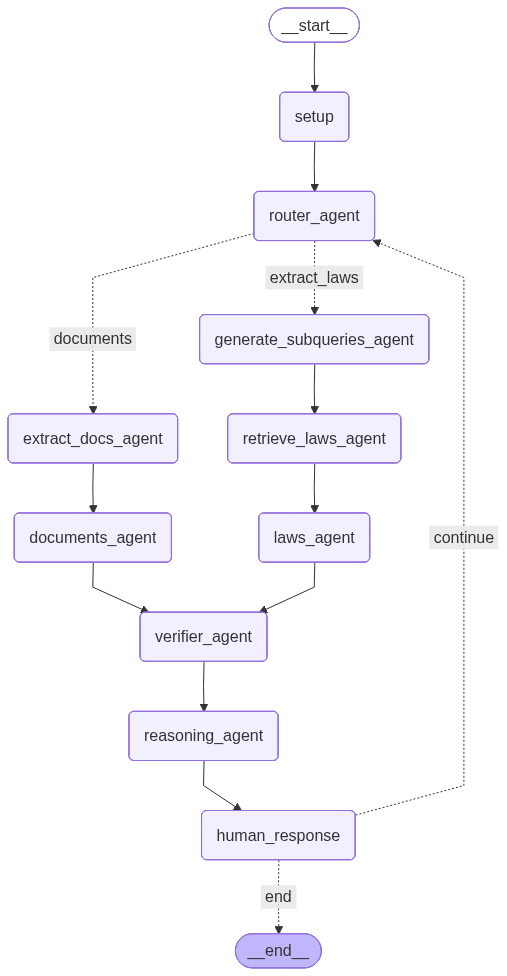

In [4]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))